In [3]:
from embeddings import (
    plot_embeddings,
    compute_marker_parameter_correlations,
    compute_marker_embedding_correlations,
    get_top_correlated_markers,
    get_significant_marker_parameter_correlations,
    plot_marker_vs_latent,
    plot_binned_dynamic_cytof,
    get_available_parameters,
    plot_embeddings_all_parameters,
    plot_marker_parameter_heatmap,
    sensitive_pars,
)

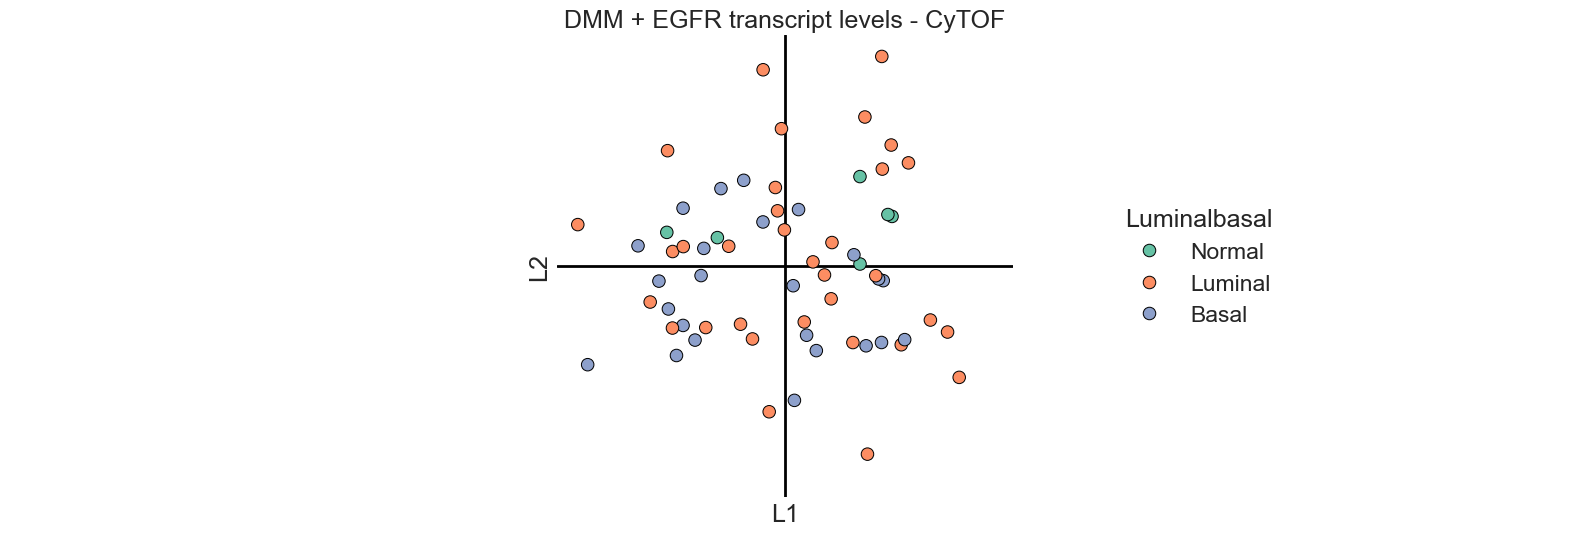

In [4]:
# Example: Plot with luminalbasal coloring
plot_embeddings(
    model="EGFR_MAPK__logobs_tegfr_aggavg",
    context="cytof_init",
    color_by="luminalbasal",
    save_path="embedding_cytof_tegfr.eps",
    palette="Set2"
);

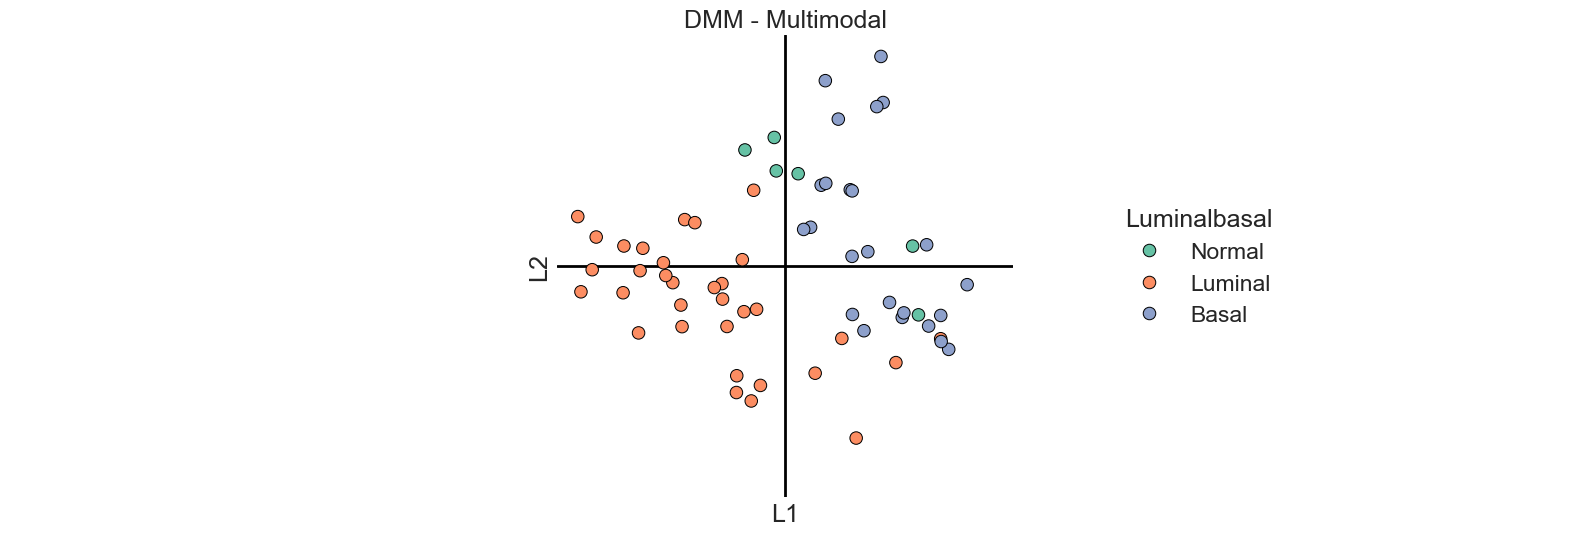

In [5]:
plot_embeddings(
    model="EGFR_MAPK__logobs",
    context="multimodal",
    color_by="luminalbasal",
    save_path="embedding_multimodal_base.eps",
    palette="Set2",
);

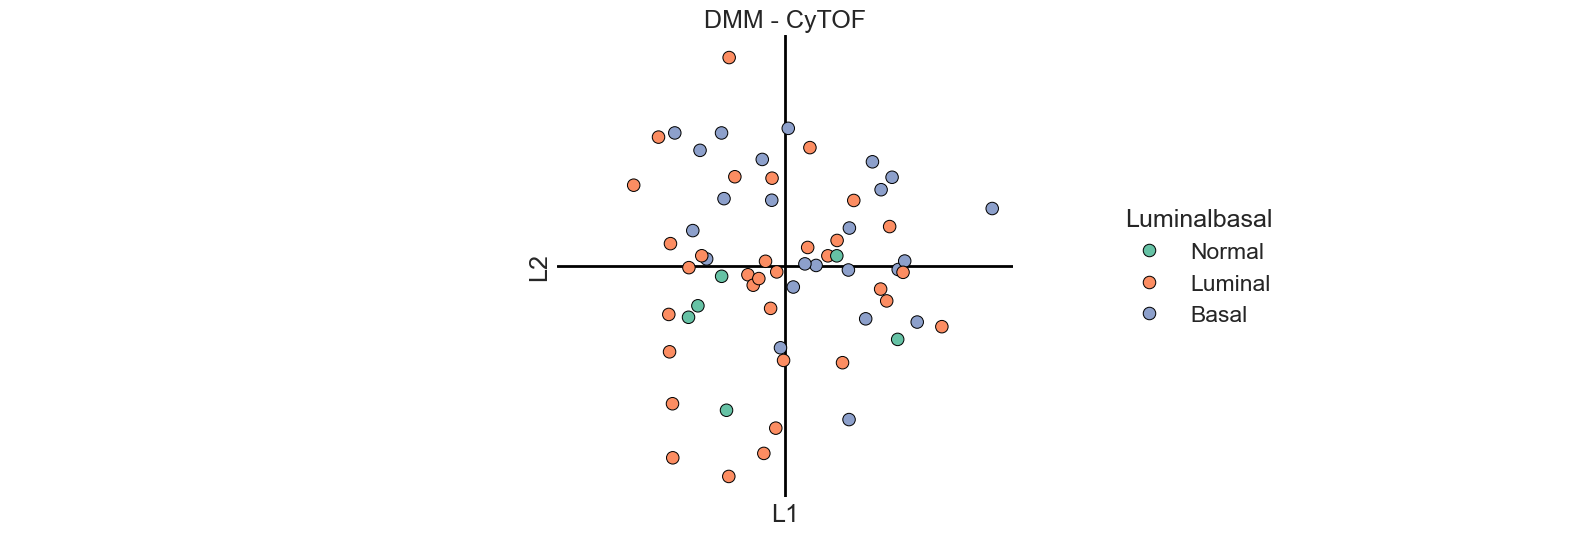

In [6]:
plot_embeddings(
    model="EGFR_MAPK__logobs",
    context="cytof_init",
    color_by="luminalbasal",
    save_path="embedding_multimodal_base.eps",
    palette="Set2",
);

## Luminal vs Basal Classification from Embeddings

Evaluate how well embeddings separate luminal from basal cell lines using cross-validated classifiers.

In [9]:
import sys
from pathlib import Path

import pandas as pd

# Ensure project root is on sys.path so we can import common, embedding_utils, etc.
_project_root = str(Path.cwd().parent)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from embedding_utils import evaluate_luminal_basal_classifier, plot_luminal_basal_performance
from common import subtypes_tognetti
from embeddings import load_embedding_data, prepare_pca_embeddings, load_marcotte_subtypes

# Load and PCA-transform embeddings once
embedding_df = load_embedding_data(figure="figure3")
subtypes_df = load_marcotte_subtypes(embedding_df.cell_line.unique())
pca_embedding_df = prepare_pca_embeddings(embedding_df, subtypes_df)

# Reset index so cell_line is a column (PCA sets it as index)
if pca_embedding_df.index.name == "cell_line":
    pca_embedding_df = pca_embedding_df.reset_index()

# Configurations to evaluate
models = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]
contexts = ["cytof_init", "multimodal"]
classifiers = ["svm", "logreg", "rf"]

all_results = []
for model in models:
    for context in contexts:
        emb_df = pca_embedding_df[
            (pca_embedding_df["model"] == model) &
            (pca_embedding_df["context"] == context)
        ].copy()
        if emb_df.empty:
            print(f"Skipping {model}/{context}: no embeddings found")
            continue
        for clf in classifiers:
            res = evaluate_luminal_basal_classifier(
                embeddings_df=emb_df,
                subtype_mapping=subtypes_tognetti,
                classifier=clf,
                group_cols=["context", "samples"],
            )
            if not res.empty:
                res["model"] = model
                all_results.append(res)

if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
    display(results_df)
else:
    print("No results generated.")

,context,samples,classifier,n_samples,n_splits,n_features,accuracy,roc_auc,model
0,cytof_init,all,svm,48,5,4,0.628889,0.868,EGFR_MAPK__logobs
1,cytof_init,all,logreg,48,5,4,0.668889,0.876,EGFR_MAPK__logobs
2,cytof_init,all,rf,48,5,4,0.582222,0.673,EGFR_MAPK__logobs
3,multimodal,all,svm,48,5,4,0.960000,1.000,EGFR_MAPK__logobs
4,multimodal,all,logreg,48,5,4,0.960000,1.000,EGFR_MAPK__logobs
5,multimodal,all,rf,48,5,4,0.915556,0.992,EGFR_MAPK__logobs
6,cytof_init,all,svm,48,5,4,0.606667,0.724,EGFR_MAPK__logobs_tegfr_aggavg
7,cytof_init,all,logreg,48,5,4,0.562222,0.718,EGFR_MAPK__logobs_tegfr_aggavg
8,cytof_init,all,rf,48,5,4,0.524444,0.542,EGFR_MAPK__logobs_tegfr_aggavg
9,multimodal,all,svm,48,5,4,0.980000,0.992,EGFR_MAPK__logobs_tegfr_aggavg


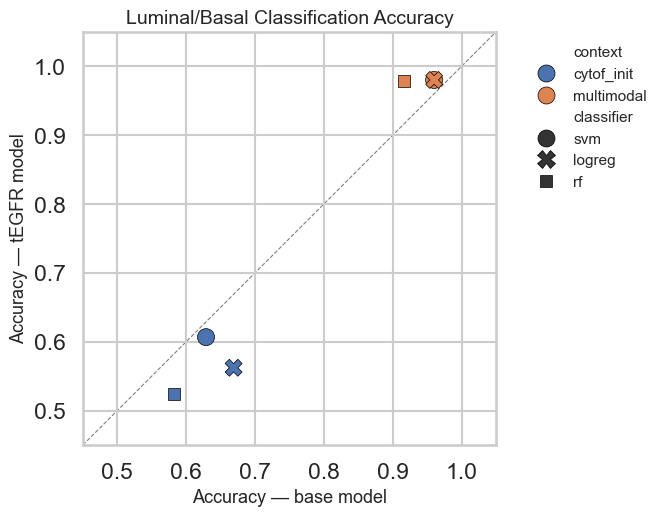

In [24]:
import seaborn as sns, matplotlib.pyplot as plt
import numpy as np

METRIC_LABELS = {"accuracy": "Accuracy", "roc_auc": "AUROC"}

def scatter_model_comparison(results_df, metric, title):
    """Scatter: x = base model, y = tegfr model, one point per (context, classifier)."""
    label = METRIC_LABELS.get(metric, metric)
    base = results_df[results_df["model"] == "EGFR_MAPK__logobs"].rename(columns={metric: "base"})
    tegfr = results_df[results_df["model"] == "EGFR_MAPK__logobs_tegfr_aggavg"].rename(columns={metric: "tegfr"})
    merged = base[["context", "samples", "classifier", "base"]].merge(
        tegfr[["context", "samples", "classifier", "tegfr"]],
        on=["context", "samples", "classifier"],
    )

    fig, ax = plt.subplots(figsize=(7, 7))
    sns.scatterplot(
        data=merged, x="base", y="tegfr",
        hue="context", style="classifier",
        s=150, edgecolor="black", linewidth=0.5, ax=ax,
    )
    lo, hi = 0.45, 1.05
    ticks = np.arange(0.5, 1.05, 0.1)
    ax.plot([lo, hi], [lo, hi], ls="--", color="grey", lw=0.8, zorder=0)
    ax.set(xlim=(lo, hi), ylim=(lo, hi))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xlabel(f"{label} — base model", fontsize=13)
    ax.set_ylabel(f"{label} — tEGFR model", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize=11)
    plt.tight_layout()
    plt.show()

if all_results:
    scatter_model_comparison(results_df, "accuracy", "Luminal/Basal Classification Accuracy")

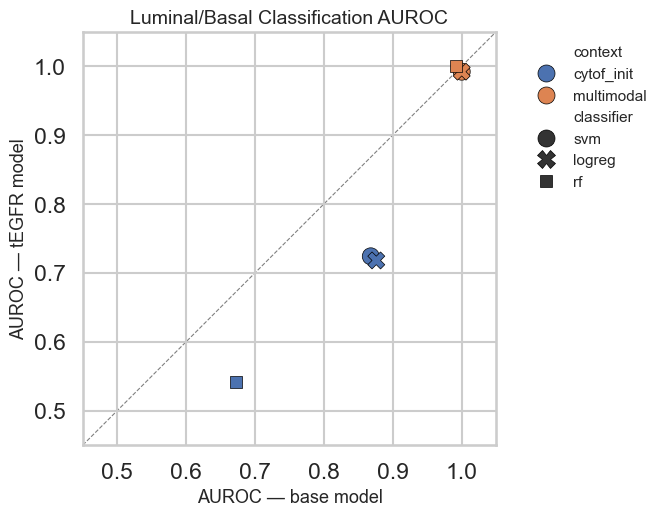

In [25]:
if all_results:
    scatter_model_comparison(results_df, "roc_auc", "Luminal/Basal Classification AUROC")